# SARIMAX H+1 (Short-Term t+1, Event-Based)

Notebook ini fokus ke forecasting **harga Close t+1** dengan pendekatan SARIMAX pada data event-based trading day.

Prinsip evaluasi:
- Walk-forward yearly
- Purged boundary (`h=1`)
- Baseline di-lock dari valid lalu dibandingkan di test
- Feature set `Core-3`: `ret_lag1`, `ret_std_10`, `log_volume_lag1`


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
np.set_printoptions(suppress=True)


In [2]:
# Paths & config
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_PATH = ROOT / 'data' / 'processed data' / 'ali_f_event_model_ready_v3.csv'
assert DATA_PATH.exists(), f'File not found: {DATA_PATH}'

H = 1
PURGE = 1
MIN_YEAR = 2020
MIN_TRAIN = 220
MIN_VALID = 80
MIN_TEST = 80

DATA_PATH


PosixPath('/home/sdo/Project/Machine Learning/INALUM/data/processed data/ali_f_event_model_ready_v3.csv')

In [3]:
# Load
raw = pd.read_csv(DATA_PATH)
raw['Date'] = pd.to_datetime(raw['Date'])
raw = raw.sort_values('Date').reset_index(drop=True)

num_cols = ['Close', 'High', 'Low', 'Open', 'Volume', 'gap_days', 'is_long_gap']
for c in num_cols:
    if c in raw.columns:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')

raw[['Date', 'Close', 'Volume', 'gap_days', 'is_long_gap']].head()


,Date,Close,Volume,gap_days,is_long_gap
0,2014-05-06,2172.75,41,NaN,False
1,2014-05-07,2149.00,35,1.0,False
2,2014-05-08,2141.75,25,1.0,False
3,2014-05-09,2107.25,14,1.0,False
4,2014-05-12,2088.25,4,3.0,False


In [4]:
# Build modeling frame (target in log-return t->t+1, then convert to price for business metrics)
df = raw.copy()

df['log_ret_1'] = np.log(df['Close'] / df['Close'].shift(1))
df['target_ret_t1'] = np.log(df['Close'].shift(-H) / df['Close'])
df['target_close_t1'] = df['Close'].shift(-H)

# Core-3 exog (strictly historical)
df['ret_lag1'] = df['log_ret_1'].shift(1)
df['ret_std_10'] = df['log_ret_1'].rolling(10, min_periods=10).std().shift(1)
df['log_volume_lag1'] = np.log1p(df['Volume']).shift(1)

# Baseline helper
# persistence of prior h-event move (known at time t)
df['mom1_persist'] = np.log(df['Close'] / df['Close'].shift(H))

# Quality filter: keep post-2020, drop long-gap rows
df = df[df['Date'].dt.year >= MIN_YEAR].copy()
df = df[df['gap_days'].fillna(1) <= 7].copy()

keep_cols = [
    'Date', 'Close', 'target_ret_t1', 'target_close_t1',
    'ret_lag1', 'ret_std_10', 'log_volume_lag1', 'mom1_persist',
    'gap_days', 'is_long_gap'
]
model_df = df[keep_cols].dropna().reset_index(drop=True)
model_df['year'] = model_df['Date'].dt.year

print('Rows:', len(model_df))
print('Date range:', model_df['Date'].min().date(), '->', model_df['Date'].max().date())
model_df.head()


Rows: 1413
Date range: 2020-01-02 -> 2026-03-03


,Date,Close,target_ret_t1,target_close_t1,ret_lag1,ret_std_10,log_volume_lag1,mom1_persist,gap_days,is_long_gap,year
0,2020-01-02,1812.50,0.009609,1830.00,-0.005193,0.005458,0.000000,-0.006599,2.0,False,2020
1,2020-01-03,1830.00,0.006536,1842.00,-0.006599,0.006133,0.000000,0.009609,1.0,False,2020
2,2020-01-06,1842.00,-0.010917,1822.00,0.009609,0.006001,0.000000,0.006536,3.0,False,2020
3,2020-01-07,1822.00,-0.010622,1802.75,0.006536,0.005872,1.609438,-0.010917,1.0,False,2020
4,2020-01-08,1802.75,0.000416,1803.50,-0.010917,0.006692,1.386294,-0.010622,1.0,False,2020


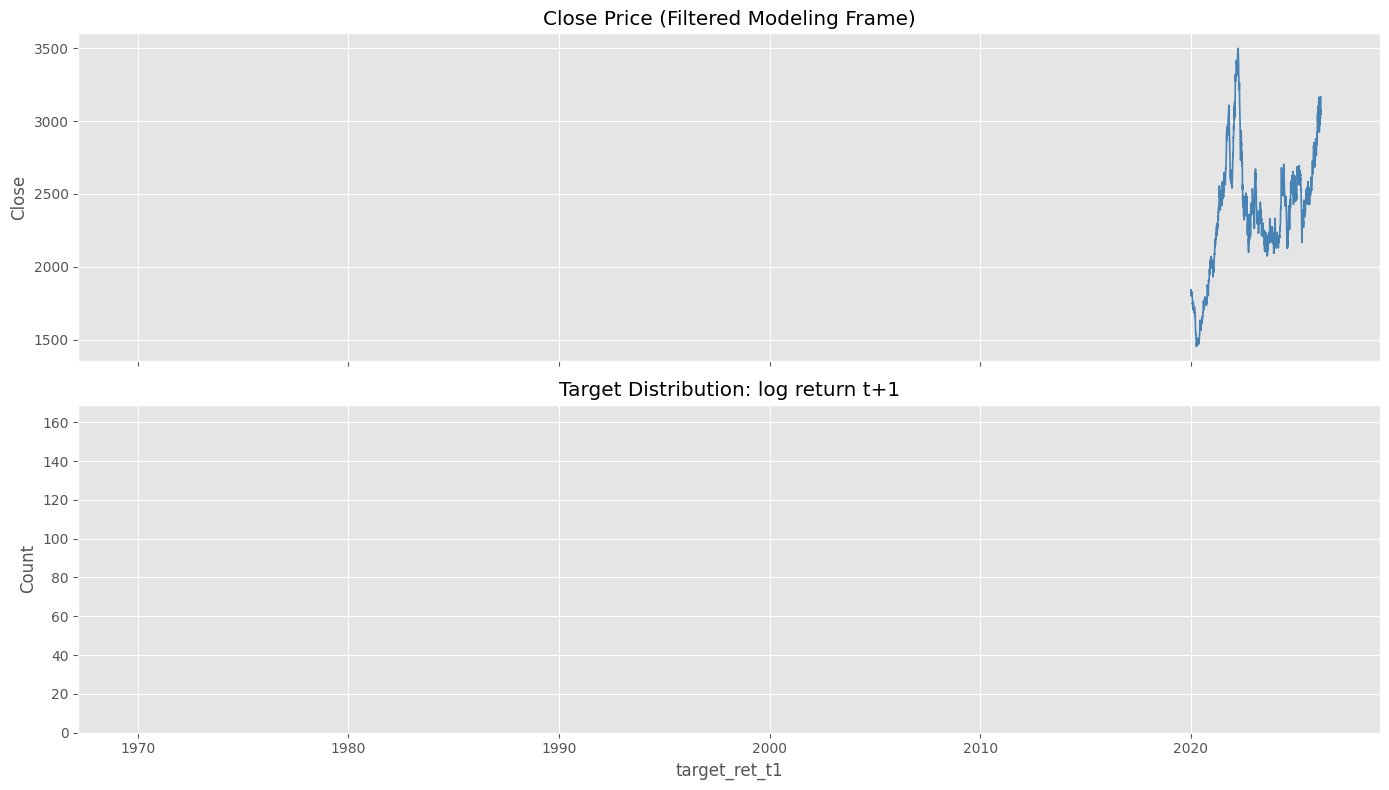

In [5]:
# Quick visual sanity
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax[0].plot(model_df['Date'], model_df['Close'], lw=1.2, color='steelblue')
ax[0].set_title('Close Price (Filtered Modeling Frame)')
ax[0].set_ylabel('Close')

ax[1].hist(model_df['target_ret_t1'], bins=60, color='darkorange', alpha=0.85)
ax[1].set_title('Target Distribution: log return t+1')
ax[1].set_xlabel('target_ret_t1')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [6]:
# Walk-forward fold builder (yearly, purged)
def build_yearly_folds(frame, purge=5, min_train=220, min_valid=80, min_test=80):
    folds = []
    years = sorted(frame['year'].unique())
    pos = np.arange(len(frame))

    for valid_year in years:
        test_year = valid_year + 1
        if test_year not in years:
            continue

        train_pos = pos[frame['year'].values < valid_year]
        valid_pos = pos[frame['year'].values == valid_year]
        test_pos = pos[frame['year'].values == test_year]

        if len(train_pos) <= purge or len(valid_pos) <= purge or len(test_pos) <= purge:
            continue

        # Purge around boundaries
        train_pos = train_pos[:-purge]
        valid_pos = valid_pos[purge:]
        test_pos = test_pos[purge:]

        if len(train_pos) < min_train or len(valid_pos) < min_valid or len(test_pos) < min_test:
            continue

        folds.append({
            'valid_year': int(valid_year),
            'test_year': int(test_year),
            'train_pos': train_pos,
            'valid_pos': valid_pos,
            'test_pos': test_pos,
        })
    return folds

folds = build_yearly_folds(
    model_df, purge=PURGE, min_train=MIN_TRAIN, min_valid=MIN_VALID, min_test=MIN_TEST
)

pd.DataFrame([
    {
        'valid_year': f['valid_year'],
        'test_year': f['test_year'],
        'train_rows': len(f['train_pos']),
        'valid_rows': len(f['valid_pos']),
        'test_rows': len(f['test_pos']),
    }
    for f in folds
])


,valid_year,test_year,train_rows,valid_rows,test_rows
0,2021,2022,239,197,198
1,2022,2023,437,198,246
2,2023,2024,636,246,236
3,2024,2025,883,236,250


In [7]:
# Metrics & helper functions
FEATURES = ['ret_lag1', 'ret_std_10', 'log_volume_lag1']
BASELINES = ['zero_return', 'mean_train_return', 'mom1_persist']


def to_price(close_t, pred_log_ret):
    return close_t * np.exp(pred_log_ret)


def eval_price_metrics(actual_price, pred_price):
    mae = mean_absolute_error(actual_price, pred_price)
    rmse = np.sqrt(mean_squared_error(actual_price, pred_price))
    return mae, rmse


def baseline_pred_logret(name, frame_slice, train_y_mean):
    if name == 'zero_return':
        return np.zeros(len(frame_slice))
    if name == 'mean_train_return':
        return np.full(len(frame_slice), train_y_mean)
    if name == 'mom1_persist':
        return frame_slice['mom1_persist'].values
    raise ValueError(name)


def fit_predict_sarimax(y_train, X_train, X_pred, order, seasonal_order):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_pred_s = scaler.transform(X_pred)

    model = SARIMAX(
        endog=y_train,
        exog=X_train_s,
        order=order,
        seasonal_order=seasonal_order,
        trend='c',
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False, maxiter=300)
    pred = fit.forecast(steps=len(X_pred_s), exog=X_pred_s)
    return np.asarray(pred)


In [8]:
# Candidate grid (small & stable first)
orders = [(1,0,0), (1,0,1), (2,0,1), (2,0,2)]
seasonals = [(0,0,0,0), (1,0,0,5)]
candidates = [(o, s) for o in orders for s in seasonals]

valid_model_rows = []
valid_baseline_rows = []

for fold_id, f in enumerate(folds, start=1):
    tr = model_df.iloc[f['train_pos']]
    va = model_df.iloc[f['valid_pos']]

    y_tr = tr['target_ret_t1'].values
    X_tr = tr[FEATURES].values
    y_va_true = va['target_close_t1'].values
    close_va = va['Close'].values

    # baselines on valid
    for b in BASELINES:
        b_logret = baseline_pred_logret(b, va, train_y_mean=float(np.mean(y_tr)))
        b_price = to_price(close_va, b_logret)
        b_mae, b_rmse = eval_price_metrics(y_va_true, b_price)
        valid_baseline_rows.append({
            'fold': fold_id,
            'valid_year': f['valid_year'],
            'baseline': b,
            'valid_mae': b_mae,
            'valid_rmse': b_rmse,
        })

    # sarimax candidates on valid
    for order, seasonal in candidates:
        try:
            pred_logret = fit_predict_sarimax(
                y_train=y_tr,
                X_train=X_tr,
                X_pred=va[FEATURES].values,
                order=order,
                seasonal_order=seasonal,
            )
            pred_price = to_price(close_va, pred_logret)
            mae, rmse = eval_price_metrics(y_va_true, pred_price)
            valid_model_rows.append({
                'fold': fold_id,
                'valid_year': f['valid_year'],
                'order': str(order),
                'seasonal': str(seasonal),
                'valid_mae': mae,
                'valid_rmse': rmse,
                'ok': True,
            })
        except Exception as e:
            valid_model_rows.append({
                'fold': fold_id,
                'valid_year': f['valid_year'],
                'order': str(order),
                'seasonal': str(seasonal),
                'valid_mae': np.nan,
                'valid_rmse': np.nan,
                'ok': False,
                'error': str(e)[:120],
            })

valid_model_df = pd.DataFrame(valid_model_rows)
valid_baseline_df = pd.DataFrame(valid_baseline_rows)

baseline_rank = (
    valid_baseline_df.groupby('baseline', as_index=False)
    .agg(mean_valid_mae=('valid_mae','mean'), mean_valid_rmse=('valid_rmse','mean'))
    .sort_values('mean_valid_mae')
)
LOCKED_BASELINE = baseline_rank.iloc[0]['baseline']

model_rank = (
    valid_model_df[valid_model_df['ok']]
    .groupby(['order','seasonal'], as_index=False)
    .agg(mean_valid_mae=('valid_mae','mean'), mean_valid_rmse=('valid_rmse','mean'))
    .sort_values('mean_valid_mae')
)
LOCKED_ORDER = eval(model_rank.iloc[0]['order'])
LOCKED_SEASONAL = eval(model_rank.iloc[0]['seasonal'])

print('LOCKED BASELINE:', LOCKED_BASELINE)
print('LOCKED SARIMAX:', LOCKED_ORDER, LOCKED_SEASONAL)


/home/sdo/Project/Machine Learning/INALUM/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sdo/Project/Machine Learning/INALUM/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sdo/Project/Machine Learning/INALUM/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sdo/Project/Machine Learning/INALUM/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum 

LOCKED BASELINE: zero_return
LOCKED SARIMAX: (2, 0, 1) (1, 0, 0, 5)


Baseline ranking (valid):


,baseline,mean_valid_mae,mean_valid_rmse
2,zero_return,28.490017,40.054125
0,mean_train_return,28.536936,40.108808
1,mom1_persist,39.580589,52.962064


Model ranking (valid):


,order,seasonal,mean_valid_mae,mean_valid_rmse
5,"(2, 0, 1)","(1, 0, 0, 5)",26.417678,37.950380
6,"(2, 0, 2)","(0, 0, 0, 0)",28.672774,40.132331
7,"(2, 0, 2)","(1, 0, 0, 5)",28.850458,40.365024
2,"(1, 0, 1)","(0, 0, 0, 0)",28.899738,40.337486
0,"(1, 0, 0)","(0, 0, 0, 0)",28.912855,40.347278
1,"(1, 0, 0)","(1, 0, 0, 5)",28.927724,40.366969
3,"(1, 0, 1)","(1, 0, 0, 5)",28.928032,40.367041
4,"(2, 0, 1)","(0, 0, 0, 0)",72.669022,103.837752


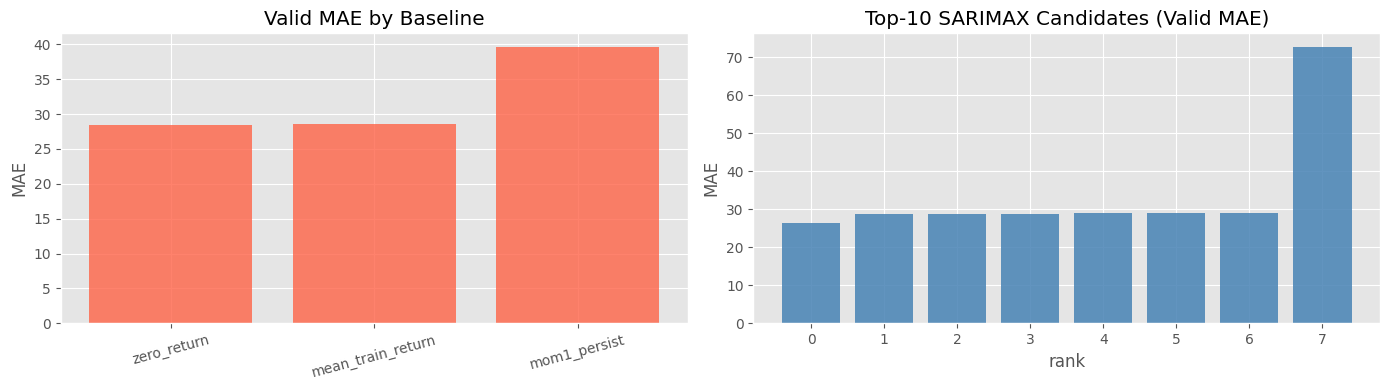

In [9]:
# Valid summary + visual
print('Baseline ranking (valid):')
display(baseline_rank)

print('Model ranking (valid):')
display(model_rank.head(10))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(baseline_rank['baseline'], baseline_rank['mean_valid_mae'], color='tomato', alpha=0.8)
ax[0].set_title('Valid MAE by Baseline')
ax[0].set_ylabel('MAE')
ax[0].tick_params(axis='x', rotation=15)

best10 = model_rank.head(10).copy()
ax[1].bar(np.arange(len(best10)), best10['mean_valid_mae'], color='steelblue', alpha=0.85)
ax[1].set_title('Top-10 SARIMAX Candidates (Valid MAE)')
ax[1].set_ylabel('MAE')
ax[1].set_xlabel('rank')

plt.tight_layout()
plt.show()


In [10]:
# Test evaluation (lock baseline & lock model from valid)
test_rows = []
pred_rows = []

for fold_id, f in enumerate(folds, start=1):
    tr = model_df.iloc[f['train_pos']]
    va = model_df.iloc[f['valid_pos']]
    te = model_df.iloc[f['test_pos']]

    # Refit with train+valid for realistic deployment before test year
    trv = pd.concat([tr, va], axis=0)

    y_trv = trv['target_ret_t1'].values
    X_trv = trv[FEATURES].values

    y_te_true = te['target_close_t1'].values
    close_te = te['Close'].values

    # Locked baseline
    b_logret = baseline_pred_logret(LOCKED_BASELINE, te, train_y_mean=float(np.mean(y_trv)))
    b_price = to_price(close_te, b_logret)
    b_mae, b_rmse = eval_price_metrics(y_te_true, b_price)

    # Locked SARIMAX
    x_logret = fit_predict_sarimax(
        y_train=y_trv,
        X_train=X_trv,
        X_pred=te[FEATURES].values,
        order=LOCKED_ORDER,
        seasonal_order=LOCKED_SEASONAL,
    )
    x_price = to_price(close_te, x_logret)
    x_mae, x_rmse = eval_price_metrics(y_te_true, x_price)

    test_rows.append({
        'fold': fold_id,
        'test_year': f['test_year'],
        'baseline': LOCKED_BASELINE,
        'baseline_test_mae': b_mae,
        'baseline_test_rmse': b_rmse,
        'sarimax_test_mae': x_mae,
        'sarimax_test_rmse': x_rmse,
        'delta_test_mae': b_mae - x_mae,
        'delta_test_rmse': b_rmse - x_rmse,
        'sarimax_beats_baseline': bool(x_mae < b_mae),
    })

    pred_rows.append(pd.DataFrame({
        'Date': te['Date'].values,
        'fold': fold_id,
        'test_year': f['test_year'],
        'actual_price_t1': y_te_true,
        'sarimax_pred_price_t1': x_price,
        'baseline_pred_price_t1': b_price,
    }))

test_df = pd.DataFrame(test_rows)
pred_df = pd.concat(pred_rows, axis=0).sort_values('Date').reset_index(drop=True)

display(test_df)
print('Mean delta_test_mae (positive=better):', test_df['delta_test_mae'].mean())
print('Fold win rate:', test_df['sarimax_beats_baseline'].mean())


/home/sdo/Project/Machine Learning/INALUM/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,fold,test_year,baseline,baseline_test_mae,baseline_test_rmse,sarimax_test_mae,sarimax_test_rmse,delta_test_mae,delta_test_rmse,sarimax_beats_baseline
0,1,2022,zero_return,37.967172,52.192830,38.327552,52.283012,-0.360380,-0.090182,False
1,2,2023,zero_return,22.876016,29.446201,23.277155,30.176774,-0.401138,-0.730573,False
2,3,2024,zero_return,24.826271,34.408747,24.824875,34.437846,0.001396,-0.029099,True
3,4,2025,zero_return,23.512000,30.343723,23.444710,30.329121,0.067290,0.014602,True


Mean delta_test_mae (positive=better): -0.17320816311239362
Fold win rate: 0.5


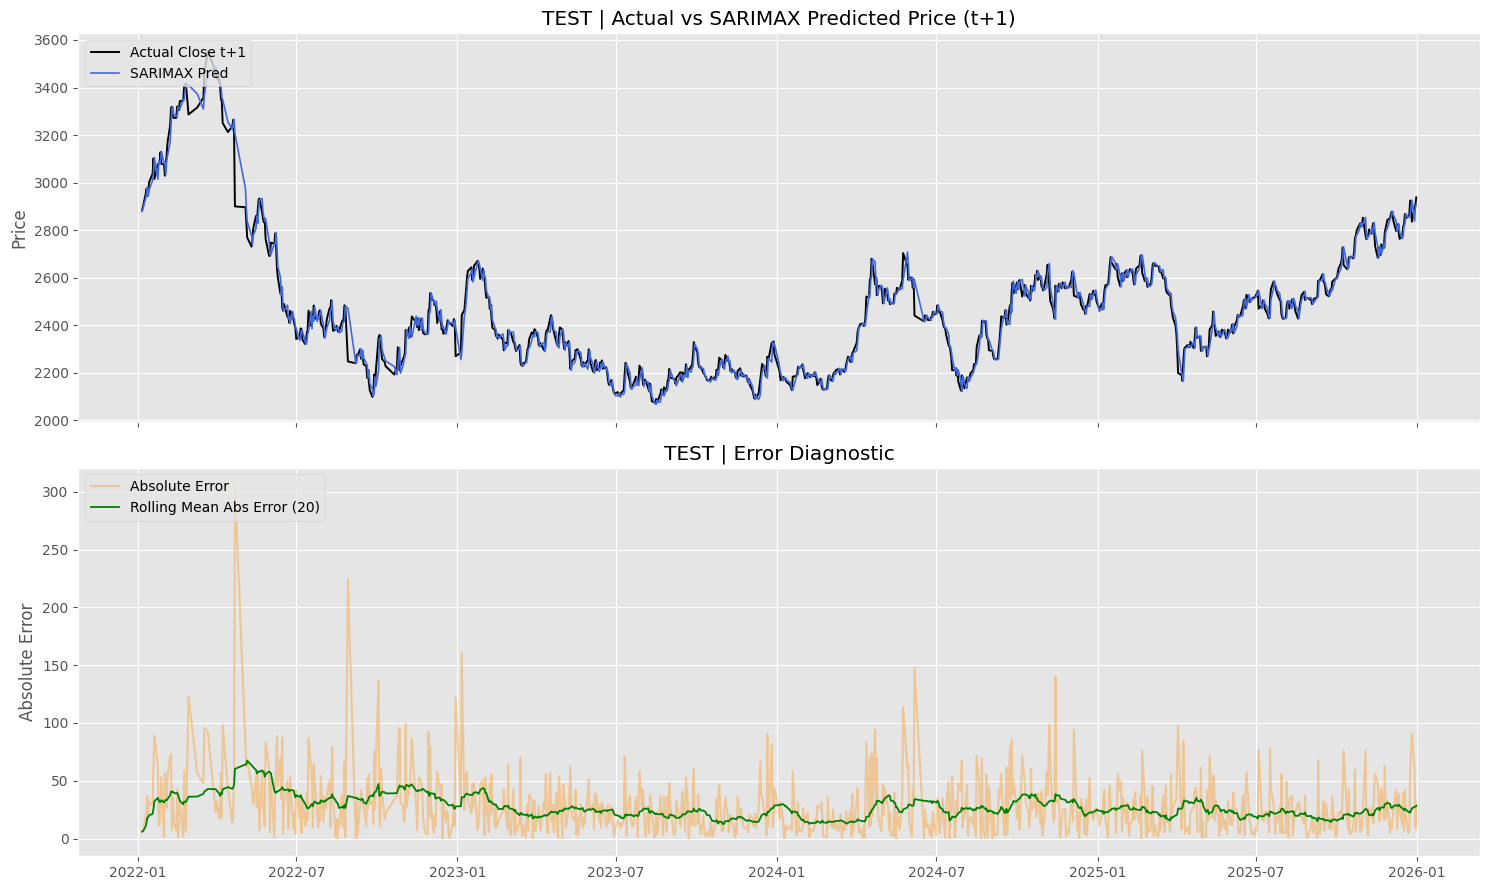

In [11]:
# Actual vs predicted (test)
fig, ax = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

ax[0].plot(pred_df['Date'], pred_df['actual_price_t1'], label='Actual Close t+1', color='black', lw=1.4)
ax[0].plot(pred_df['Date'], pred_df['sarimax_pred_price_t1'], label='SARIMAX Pred', color='royalblue', lw=1.2)
ax[0].set_title('TEST | Actual vs SARIMAX Predicted Price (t+1)')
ax[0].set_ylabel('Price')
ax[0].legend(loc='upper left')

err = np.abs(pred_df['actual_price_t1'] - pred_df['sarimax_pred_price_t1'])
roll_err = err.rolling(20, min_periods=1).mean()
ax2 = ax[1]
ax2.plot(pred_df['Date'], err, color='darkorange', alpha=0.35, label='Absolute Error')
ax2.plot(pred_df['Date'], roll_err, color='green', lw=1.3, label='Rolling Mean Abs Error (20)')
ax2.set_title('TEST | Error Diagnostic')
ax2.set_ylabel('Absolute Error')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


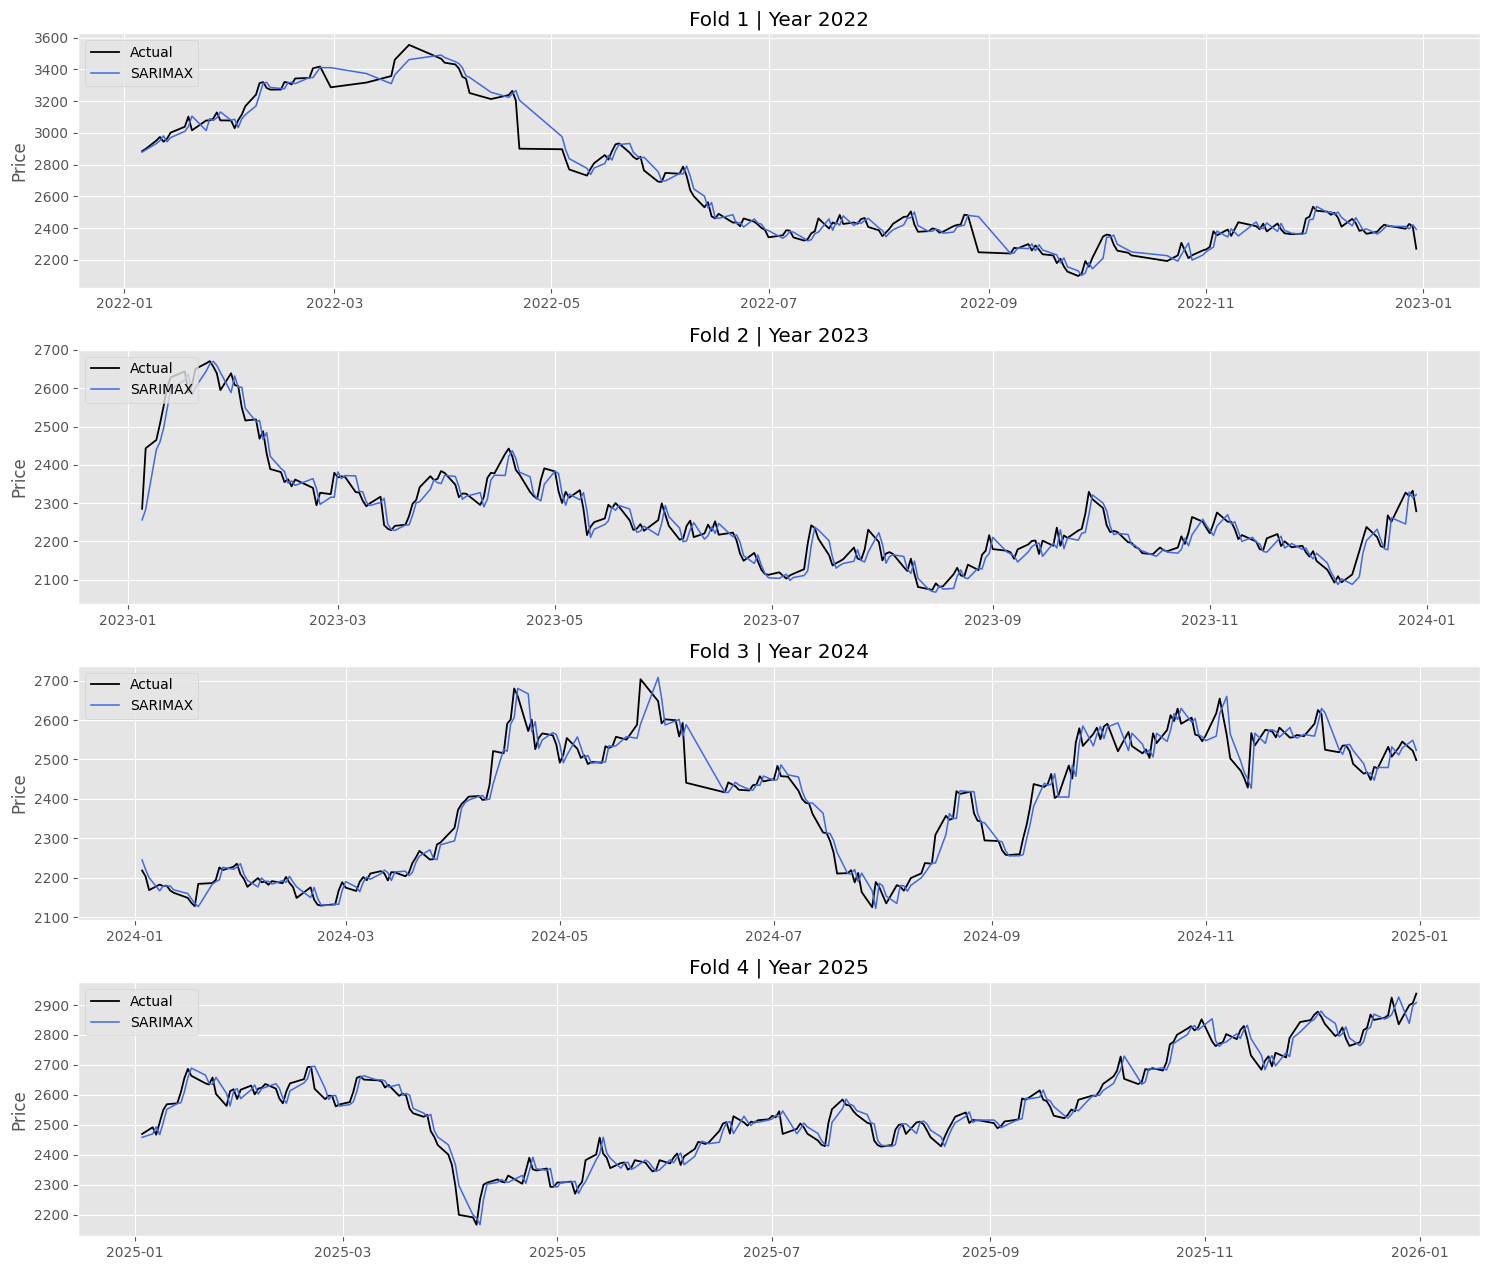

In [12]:
# Fold-by-fold chart (actual vs SARIMAX)
fold_ids = sorted(pred_df['fold'].unique())
fig, axes = plt.subplots(len(fold_ids), 1, figsize=(15, 3.2*len(fold_ids)), sharex=False)
if len(fold_ids) == 1:
    axes = [axes]

for ax, fid in zip(axes, fold_ids):
    p = pred_df[pred_df['fold'] == fid]
    ax.plot(p['Date'], p['actual_price_t1'], color='black', lw=1.3, label='Actual')
    ax.plot(p['Date'], p['sarimax_pred_price_t1'], color='royalblue', lw=1.1, label='SARIMAX')
    ax.set_title(f'Fold {fid} | Year {int(p["test_year"].iloc[0])}')
    ax.set_ylabel('Price')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [13]:
# Decision gate summary
gate = {
    'locked_baseline': LOCKED_BASELINE,
    'locked_order': LOCKED_ORDER,
    'locked_seasonal': LOCKED_SEASONAL,
    'test_mean_delta_mae': float(test_df['delta_test_mae'].mean()),
    'test_fold_win_rate': float(test_df['sarimax_beats_baseline'].mean()),
}

gate_df = pd.DataFrame([gate])
display(gate_df)

if gate['test_mean_delta_mae'] > 0:
    print('GO (relative to locked baseline): SARIMAX improves mean test MAE.')
else:
    print('NO-GO (relative to locked baseline): SARIMAX not yet consistently better on test MAE.')


,locked_baseline,locked_order,locked_seasonal,test_mean_delta_mae,test_fold_win_rate
0,zero_return,"(2, 0, 1)","(1, 0, 0, 5)",-0.173208,0.5


NO-GO (relative to locked baseline): SARIMAX not yet consistently better on test MAE.


## Next Iteration (if needed)
1. Tetap `Core-3`, coba tuning kecil seasonal (`m=5` vs `m=22`).
2. Tambah 1 fitur saja (`range_pct_lag1`) lalu cek robust gain antar fold.
3. Jika tetap tidak no-harm, jalankan Prophet sebagai pembanding sekunder (bukan pengganti evaluasi ketat).
